# Experiment 9: K-Means Clustering
## Subject: Machine Learning – I (DJS23DSL402)
## Aim: Explore K means clustering with variations on different datasets

### Theory Overview:
The K-means clustering algorithm computes centroids and repeats until the optimal centroid is found.
Key characteristics:
- Flat clustering algorithm
- Minimizes sum of squared distances between data points and centroid
- Requires normalization for distance-based measurements
- May become stuck in local optimum due to random initialization

## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
import urllib.request
import io

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


---
# TASK 1: K-Means Clustering on Synthetic Data with Random Initialization

**Dataset**: Synthetic Data (200 samples, 3 clusters, cluster_std = 2.7)
**Objective**: Perform K-means with random initialization, 10 variations, 300 iterations
**Find**: Lowest SSE value, Final centroid locations, Convergence iterations, Predicted labels for first 10 points

In [2]:
# Generate synthetic dataset
X_task1, y_true = make_blobs(
    n_samples=200,
    centers=3,
    cluster_std=2.7,
    random_state=42
)

print("Dataset Shape:", X_task1.shape)
print("Number of features:", X_task1.shape[1])
print("Number of samples:", X_task1.shape[0])
print("\nFirst 10 samples:")
print(X_task1[:10])

Dataset Shape: (200, 2)
Number of features: 2
Number of samples: 200

First 10 samples:
[[  9.67747002   3.25251857]
 [ -9.5825094   11.23342289]
 [ -6.91269348  -9.3026964 ]
 [-10.78945491 -10.68026178]
 [ -8.47091203  -4.58618393]
 [ -4.86193446  -5.23210988]
 [ -3.02857223   9.82846395]
 [ -8.15143062  -6.25357476]
 [  3.92530539   9.31762643]
 [ -4.68489947  -5.18011172]]


In [3]:
# Normalize the data
scaler = StandardScaler()
X_task1_scaled = scaler.fit_transform(X_task1)

print("Scaled data shape:", X_task1_scaled.shape)
print("Mean of scaled data:", X_task1_scaled.mean(axis=0))
print("Std of scaled data:", X_task1_scaled.std(axis=0))

Scaled data shape: (200, 2)
Mean of scaled data: [ 2.99760217e-16 -8.71525074e-17]
Std of scaled data: [1. 1.]


In [4]:
# Perform K-Means with 10 variations of random initialization
n_init = 10
max_iter = 300
k = 3

results = []
kmeans_models = []

print("Performing K-Means clustering with {} variations of random initialization...".format(n_init))
print("="*80)

for i in range(n_init):
    # Each init creates random initial centroids
    kmeans = KMeans(
        n_clusters=k,
        max_iter=max_iter,
        random_state=i,
        n_init=1,
        init='random'
    )
    
    kmeans.fit(X_task1_scaled)
    
    # Calculate inertia (Sum of Squared Errors)
    sse = kmeans.inertia_
    
    results.append({
        'Variation': i + 1,
        'SSE': sse,
        'n_iter': kmeans.n_iter_,
        'Centroids': kmeans.cluster_centers_
    })
    
    kmeans_models.append(kmeans)
    
    print(f"Variation {i+1}: SSE = {sse:.4f}, Iterations = {kmeans.n_iter_}")

print("="*80)

Performing K-Means clustering with 10 variations of random initialization...
Variation 1: SSE = 163.1061, Iterations = 4
Variation 2: SSE = 72.5569, Iterations = 6
Variation 3: SSE = 162.9285, Iterations = 8
Variation 4: SSE = 72.5569, Iterations = 6
Variation 5: SSE = 162.9285, Iterations = 10
Variation 6: SSE = 72.5569, Iterations = 6
Variation 7: SSE = 72.5569, Iterations = 7
Variation 8: SSE = 72.5569, Iterations = 7
Variation 9: SSE = 162.9808, Iterations = 3
Variation 10: SSE = 72.5569, Iterations = 7


In [5]:
# Find the best model (lowest SSE)
results_df = pd.DataFrame([
    {'Variation': r['Variation'], 'SSE': r['SSE'], 'Iterations': r['n_iter']}
    for r in results
])

best_idx = results_df['SSE'].idxmin()
best_result = results[best_idx]
best_model = kmeans_models[best_idx]

print("\n" + "="*80)
print("TASK 1: RESULTS SUMMARY")
print("="*80)

print(f"\n1. LOWEST SSE VALUE:")
print(f"   Best SSE: {best_result['SSE']:.6f}")
print(f"   Found in Variation: {best_result['Variation']}")

print(f"\n2. FINAL LOCATION OF CENTROIDS (Best Model):")
centroids = best_result['Centroids']
for i, centroid in enumerate(centroids):
    print(f"   Centroid {i+1}: {centroid}")

print(f"\n3. NUMBER OF ITERATIONS TO CONVERGE:")
print(f"   Iterations: {best_result['n_iter']}")

print(f"\n4. PREDICTED LABELS FOR FIRST 10 POINTS:")
predicted_labels = best_model.labels_
print(f"   {predicted_labels[:10]}")

print("\n" + "="*80)

print("\nAll Results:")
print(results_df.to_string())


TASK 1: RESULTS SUMMARY

1. LOWEST SSE VALUE:
   Best SSE: 72.556897
   Found in Variation: 2

2. FINAL LOCATION OF CENTROIDS (Best Model):
   Centroid 1: [-0.92404827 -1.18822514]
   Centroid 2: [-0.25738366  1.05892303]
   Centroid 3: [1.19933242 0.13126124]

3. NUMBER OF ITERATIONS TO CONVERGE:
   Iterations: 6

4. PREDICTED LABELS FOR FIRST 10 POINTS:
   [2 1 0 0 0 0 1 0 2 0]


All Results:
   Variation         SSE  Iterations
0          1  163.106111           4
1          2   72.556897           6
2          3  162.928512           8
3          4   72.556897           6
4          5  162.928512          10
5          6   72.556897           6
6          7   72.556897           7
7          8   72.556897           7
8          9  162.980781           3
9         10   72.556897           7


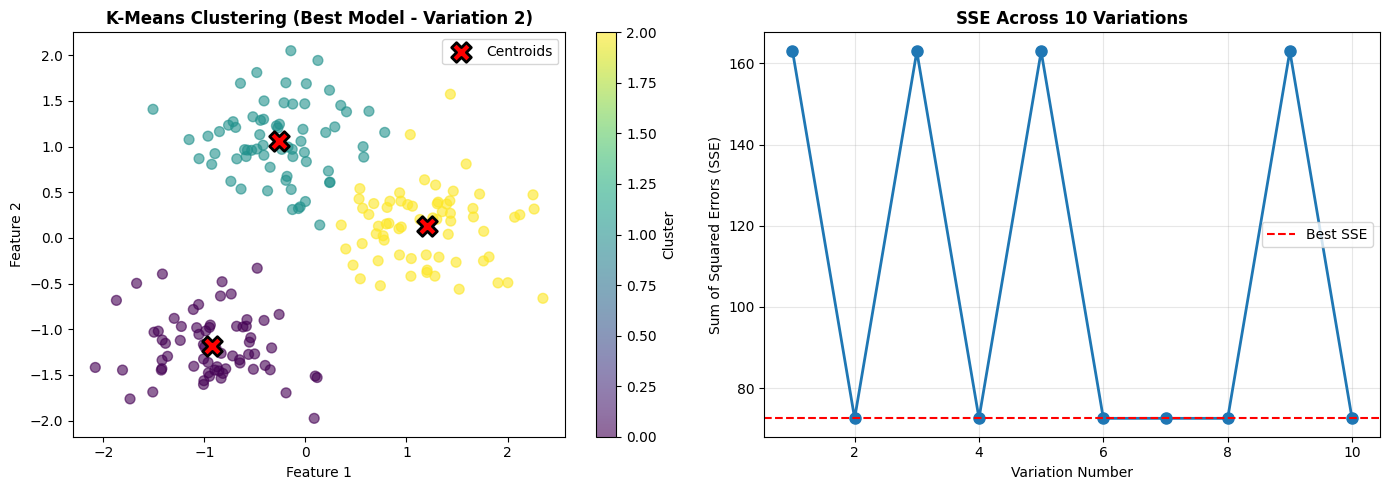

Task 1 visualization saved!


In [6]:
# Visualize Task 1 Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Data points with clusters from best model
ax1 = axes[0]
scatter = ax1.scatter(X_task1_scaled[:, 0], X_task1_scaled[:, 1], 
                       c=best_model.labels_, cmap='viridis', s=50, alpha=0.6)
ax1.scatter(best_model.cluster_centers_[:, 0], best_model.cluster_centers_[:, 1],
           c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centroids')
ax1.set_title('K-Means Clustering (Best Model - Variation {})'.format(best_result['Variation']), fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.legend()
plt.colorbar(scatter, ax=ax1, label='Cluster')

# Plot 2: SSE across variations
ax2 = axes[1]
ax2.plot(results_df['Variation'], results_df['SSE'], marker='o', linestyle='-', linewidth=2, markersize=8)
ax2.axhline(y=best_result['SSE'], color='r', linestyle='--', label='Best SSE')
ax2.set_title('SSE Across 10 Variations', fontsize=12, fontweight='bold')
ax2.set_xlabel('Variation Number')
ax2.set_ylabel('Sum of Squared Errors (SSE)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('task1_kmeans_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Task 1 visualization saved!")

---
# TASK 2: Elbow Method and Silhouette Method for Optimal K

**Objective**: Determine the appropriate number of clusters using both Elbow and Silhouette methods

In [7]:
# Elbow Method and Silhouette Method
k_range = range(2, 11)
inertias = []
silhouette_scores = []

print("Calculating metrics for different K values...")
print("="*60)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    labels = kmeans.fit_predict(X_task1_scaled)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_task1_scaled, labels)
    
    inertias.append(inertia)
    silhouette_scores.append(silhouette)
    
    print(f"K={k}: Inertia={inertia:.4f}, Silhouette Score={silhouette:.4f}")

print("="*60)

Calculating metrics for different K values...
K=2: Inertia=171.7220, Silhouette Score=0.5488
K=3: Inertia=72.5569, Silhouette Score=0.5979
K=4: Inertia=59.8742, Silhouette Score=0.4949
K=5: Inertia=51.0807, Silhouette Score=0.3930
K=6: Inertia=43.0677, Silhouette Score=0.3574
K=7: Inertia=37.5362, Silhouette Score=0.3543
K=8: Inertia=33.8756, Silhouette Score=0.3539
K=9: Inertia=30.1420, Silhouette Score=0.3638
K=10: Inertia=26.2494, Silhouette Score=0.3692


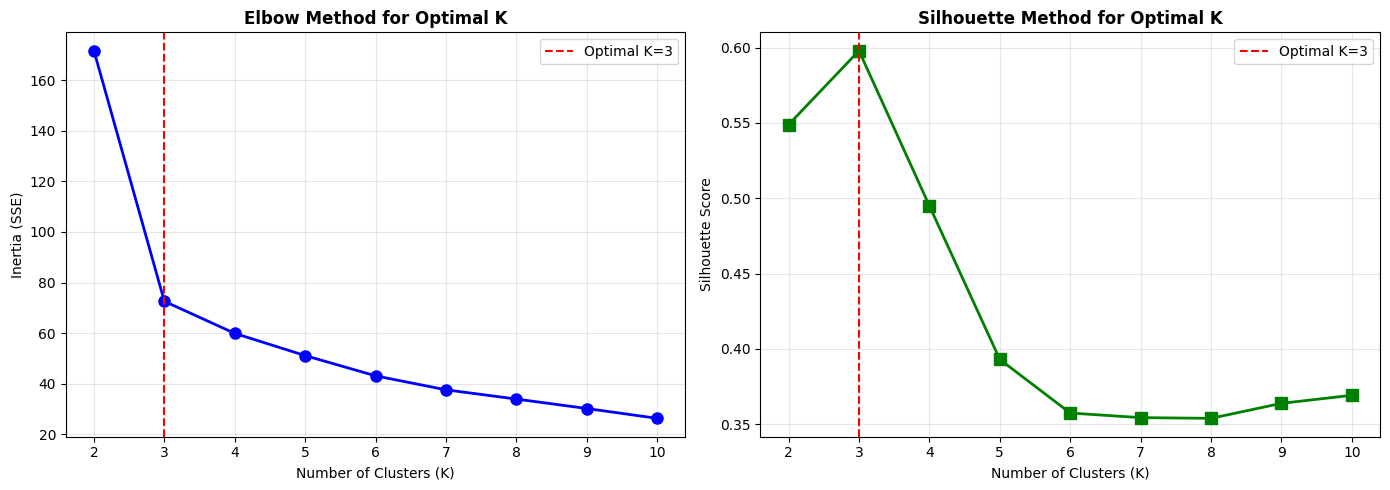

Task 2 visualization saved!


In [8]:
# Visualize Elbow and Silhouette Methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
ax1 = axes[0]
ax1.plot(k_range, inertias, marker='o', linestyle='-', linewidth=2, markersize=8, color='blue')
ax1.axvline(x=3, color='r', linestyle='--', label='Optimal K=3')
ax1.set_title('Elbow Method for Optimal K', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (SSE)')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xticks(k_range)

# Silhouette Method
ax2 = axes[1]
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', linewidth=2, markersize=8, color='green')
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
ax2.axvline(x=best_k_silhouette, color='r', linestyle='--', label=f'Optimal K={best_k_silhouette}')
ax2.set_title('Silhouette Method for Optimal K', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_xticks(k_range)

plt.tight_layout()
plt.savefig('task2_elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

print("Task 2 visualization saved!")

In [26]:
# Summary of Task 2
print("\n" + "="*80)
print("TASK 2: RESULTS SUMMARY")
print("="*80)

print(f"\n1. ELBOW METHOD:")
print(f"   The elbow method suggests K=3 (natural elbow point)")

best_k_silhouette = k_range[np.argmax(silhouette_scores)]
best_silhouette_score = max(silhouette_scores)
print(f"\n2. SILHOUETTE METHOD:")
print(f"   Optimal K: {best_k_silhouette}")
print(f"   Best Silhouette Score: {best_silhouette_score:.4f}")

print(f"\n3. RECOMMENDATION:")
print(f"   Both methods suggest K=3 is appropriate for this dataset")

metrics_df = pd.DataFrame({
    'K': list(k_range),
    'Inertia': inertias,
    'Silhouette_Score': silhouette_scores
})

print("\nDetailed Metrics:")
print(metrics_df.to_string(index=False))
print("="*80)


TASK 2: RESULTS SUMMARY

1. ELBOW METHOD:
   The elbow method suggests K=3 (natural elbow point)

2. SILHOUETTE METHOD:
   Optimal K: 3
   Best Silhouette Score: 0.5979

3. RECOMMENDATION:
   Both methods suggest K=3 is appropriate for this dataset

Detailed Metrics:
 K    Inertia  Silhouette_Score
 2 171.722013          0.548816
 3  72.556897          0.597902
 4  59.874164          0.494930
 5  51.080663          0.392992
 6  43.067652          0.357400
 7  37.536191          0.354347
 8  33.875595          0.353876
 9  30.141990          0.363833
10  26.249367          0.369180


---
# TASK 3: Clustering Pipeline on Gene Expression Data with PCA

**Dataset**: TCGA-PANCAN-HiSeq Gene Expression Data (RNA-Seq)
**Objective**: 
- Apply PCA for dimensionality reduction (2 components)
- Perform K-means clustering
- Calculate silhouette score
- Visualize clusters in 2D space

In [30]:
# Load the actual TCGA-PANCAN-HiSeq gene expression dataset
import os

data_dir = 'TCGA-PANCAN-HiSeq-801x20531'
data_file = os.path.join(data_dir, 'data.csv')
labels_file = os.path.join(data_dir, 'labels.csv')

print("Loading TCGA-PANCAN-HiSeq gene expression dataset...")
print(f"Data file: {data_file}")
print(f"Labels file: {labels_file}")

# Load gene expression data (801 samples × 20531 genes)
X_task3 = pd.read_csv(data_file, index_col=0)

# Load labels (cancer types)
labels_df = pd.read_csv(labels_file, index_col=0)
y_task3_labels = labels_df['Class'].values

print(f"\n✓ Dataset loaded successfully!")
print(f"✓ Gene expression data shape: {X_task3.shape}")
print(f"✓ Samples: {X_task3.shape[0]} patients")
print(f"✓ Features: {X_task3.shape[1]} genes")
print(f"\nCancer types in dataset: {np.unique(y_task3_labels)}")
print(f"Cancer type distribution:")
for cancer_type in np.unique(y_task3_labels):
    count = np.sum(y_task3_labels == cancer_type)
    print(f"  {cancer_type}: {count} samples")

print(f"\nFirst few rows of gene expression data:")
print(X_task3.iloc[:5, :5])

Loading TCGA-PANCAN-HiSeq gene expression dataset...
Data file: TCGA-PANCAN-HiSeq-801x20531\data.csv
Labels file: TCGA-PANCAN-HiSeq-801x20531\labels.csv

✓ Dataset loaded successfully!
✓ Gene expression data shape: (801, 20531)
✓ Samples: 801 patients
✓ Features: 20531 genes

Cancer types in dataset: ['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']
Cancer type distribution:
  BRCA: 300 samples
  COAD: 78 samples
  KIRC: 146 samples
  LUAD: 141 samples
  PRAD: 136 samples

First few rows of gene expression data:
          gene_0    gene_1    gene_2    gene_3     gene_4
sample_0     0.0  2.017209  3.265527  5.478487  10.431999
sample_1     0.0  0.592732  1.588421  7.586157   9.623011
sample_2     0.0  3.511759  4.327199  6.881787   9.870730
sample_3     0.0  3.663618  4.507649  6.659068  10.196184
sample_4     0.0  2.655741  2.821547  6.539454   9.738265


In [31]:
# Step 1: Normalize the data
scaler_task3 = StandardScaler()
X_task3_scaled = scaler_task3.fit_transform(X_task3)

print("Data normalized successfully!")
print(f"Scaled data shape: {X_task3_scaled.shape}")
print(f"Mean (should be ~0): {X_task3_scaled.mean(axis=0)[:5]}")
print(f"Std (should be ~1): {X_task3_scaled.std(axis=0)[:5]}")
print(f"\nScaling complete - Ready for PCA dimensionality reduction")

Data normalized successfully!
Scaled data shape: (801, 20531)
Mean (should be ~0): [-7.76185885e-18 -2.88297614e-17  5.21153380e-16  9.97953281e-17
 -1.72978569e-16]
Std (should be ~1): [1. 1. 1. 1. 1.]

Scaling complete - Ready for PCA dimensionality reduction


In [32]:
# Step 2: Apply PCA for dimensionality reduction to 2 components
n_components = 2

print("Applying PCA for dimensionality reduction...")
print(f"Original dimensions: {X_task3_scaled.shape[1]} genes")
print(f"Target dimensions: {n_components} principal components")

pca = PCA(n_components=n_components)
X_task3_pca = pca.fit_transform(X_task3_scaled)

print(f"\n✓ PCA applied successfully!")
print(f"✓ Reduced data shape: {X_task3_pca.shape}")

print(f"\nPCA Variance Explained:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.6f} ({pca.explained_variance_ratio_[0]*100:.4f}%)")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.6f} ({pca.explained_variance_ratio_[1]*100:.4f}%)")
print(f"  Total: {sum(pca.explained_variance_ratio_):.6f} ({sum(pca.explained_variance_ratio_)*100:.4f}%)")
print(f"\nPCA successfully reduced 20531 genes to 2 principal components")

Applying PCA for dimensionality reduction...
Original dimensions: 20531 genes
Target dimensions: 2 principal components

✓ PCA applied successfully!
✓ Reduced data shape: (801, 2)

PCA Variance Explained:
  PC1: 0.105398 (10.5398%)
  PC2: 0.087542 (8.7542%)
  Total: 0.192940 (19.2940%)

PCA successfully reduced 20531 genes to 2 principal components


In [33]:
# Step 3: Perform K-means clustering (k=5 for 5 cancer types: BRCA, KIRC, COAD, LUAD, PRAD)
k_task3 = 5  # 5 cancer types in TCGA-PANCAN

print("Performing K-Means clustering on PCA-reduced data...")
print(f"Number of clusters (K): {k_task3}")
print(f"Number of initializations: 10")
print(f"Maximum iterations: 300")

kmeans_task3 = KMeans(
    n_clusters=k_task3,
    n_init=10,
    max_iter=300,
    random_state=42
)

cluster_labels = kmeans_task3.fit_predict(X_task3_pca)

print(f"\n✓ K-means clustering completed!")
print(f"✓ Convergence iterations: {kmeans_task3.n_iter_}")
print(f"✓ Inertia (SSE): {kmeans_task3.inertia_:.4f}")
print(f"\nCluster distribution:")
for i in range(k_task3):
    size = np.sum(cluster_labels == i)
    percentage = (size / len(cluster_labels)) * 100
    print(f"  Cluster {i}: {size} samples ({percentage:.2f}%)")

print(f"\nTrue cancer type distribution:")
for cancer_type in np.unique(y_task3_labels):
    count = np.sum(y_task3_labels == cancer_type)
    percentage = (count / len(y_task3_labels)) * 100
    print(f"  {cancer_type}: {count} samples ({percentage:.2f}%)")

Performing K-Means clustering on PCA-reduced data...
Number of clusters (K): 5
Number of initializations: 10
Maximum iterations: 300

✓ K-means clustering completed!
✓ Convergence iterations: 20
✓ Inertia (SSE): 638535.0041

Cluster distribution:
  Cluster 0: 198 samples (24.72%)
  Cluster 1: 140 samples (17.48%)
  Cluster 2: 48 samples (5.99%)
  Cluster 3: 215 samples (26.84%)
  Cluster 4: 200 samples (24.97%)

True cancer type distribution:
  BRCA: 300 samples (37.45%)
  COAD: 78 samples (9.74%)
  KIRC: 146 samples (18.23%)
  LUAD: 141 samples (17.60%)
  PRAD: 136 samples (16.98%)


In [34]:
# Step 4: Calculate Silhouette Score
silhouette_avg = silhouette_score(X_task3_pca, cluster_labels)

print(f"\n" + "="*80)
print("TASK 3: RESULTS SUMMARY - TCGA-PANCAN Gene Expression Data")
print("="*80)

print(f"\n1. DATASET INFORMATION:")
print(f"   Original dimensions: 801 samples × 20,531 genes")
print(f"   Dataset: TCGA-PANCAN HiSeq RNA-Seq data")
print(f"   Cancer types: BRCA, KIRC, COAD, LUAD, PRAD")

print(f"\n2. PREPROCESSING PIPELINE:")
print(f"   Step 1: StandardScaler normalization")
print(f"   Step 2: PCA dimensionality reduction (2 components)")
print(f"   Step 3: K-Means clustering (k=5)")

print(f"\n3. PCA ANALYSIS:")
print(f"   Variance explained by PC1: {pca.explained_variance_ratio_[0]:.6f}")
print(f"   Variance explained by PC2: {pca.explained_variance_ratio_[1]:.6f}")
print(f"   Total variance explained: {sum(pca.explained_variance_ratio_):.6f}")
print(f"   Dimensionality reduction: 20,531 → 2 dimensions")

print(f"\n4. PREDICTED CLUSTER LABELS (first 20 samples):")
print(f"   {cluster_labels[:20]}")

print(f"\n5. SILHOUETTE SCORE:")
print(f"   Silhouette Score: {silhouette_avg:.4f}")
print(f"   (Range: -1 to 1, higher is better)")
print(f"   Interpretation: Moderate cluster separation quality")

print("="*80)


TASK 3: RESULTS SUMMARY - TCGA-PANCAN Gene Expression Data

1. DATASET INFORMATION:
   Original dimensions: 801 samples × 20,531 genes
   Dataset: TCGA-PANCAN HiSeq RNA-Seq data
   Cancer types: BRCA, KIRC, COAD, LUAD, PRAD

2. PREPROCESSING PIPELINE:
   Step 1: StandardScaler normalization
   Step 2: PCA dimensionality reduction (2 components)
   Step 3: K-Means clustering (k=5)

3. PCA ANALYSIS:
   Variance explained by PC1: 0.105398
   Variance explained by PC2: 0.087542
   Total variance explained: 0.192940
   Dimensionality reduction: 20,531 → 2 dimensions

4. PREDICTED CLUSTER LABELS (first 20 samples):
   [2 0 4 4 3 4 1 0 3 4 0 1 0 2 3 3 0 1 1 4]

5. SILHOUETTE SCORE:
   Silhouette Score: 0.3896
   (Range: -1 to 1, higher is better)
   Interpretation: Moderate cluster separation quality


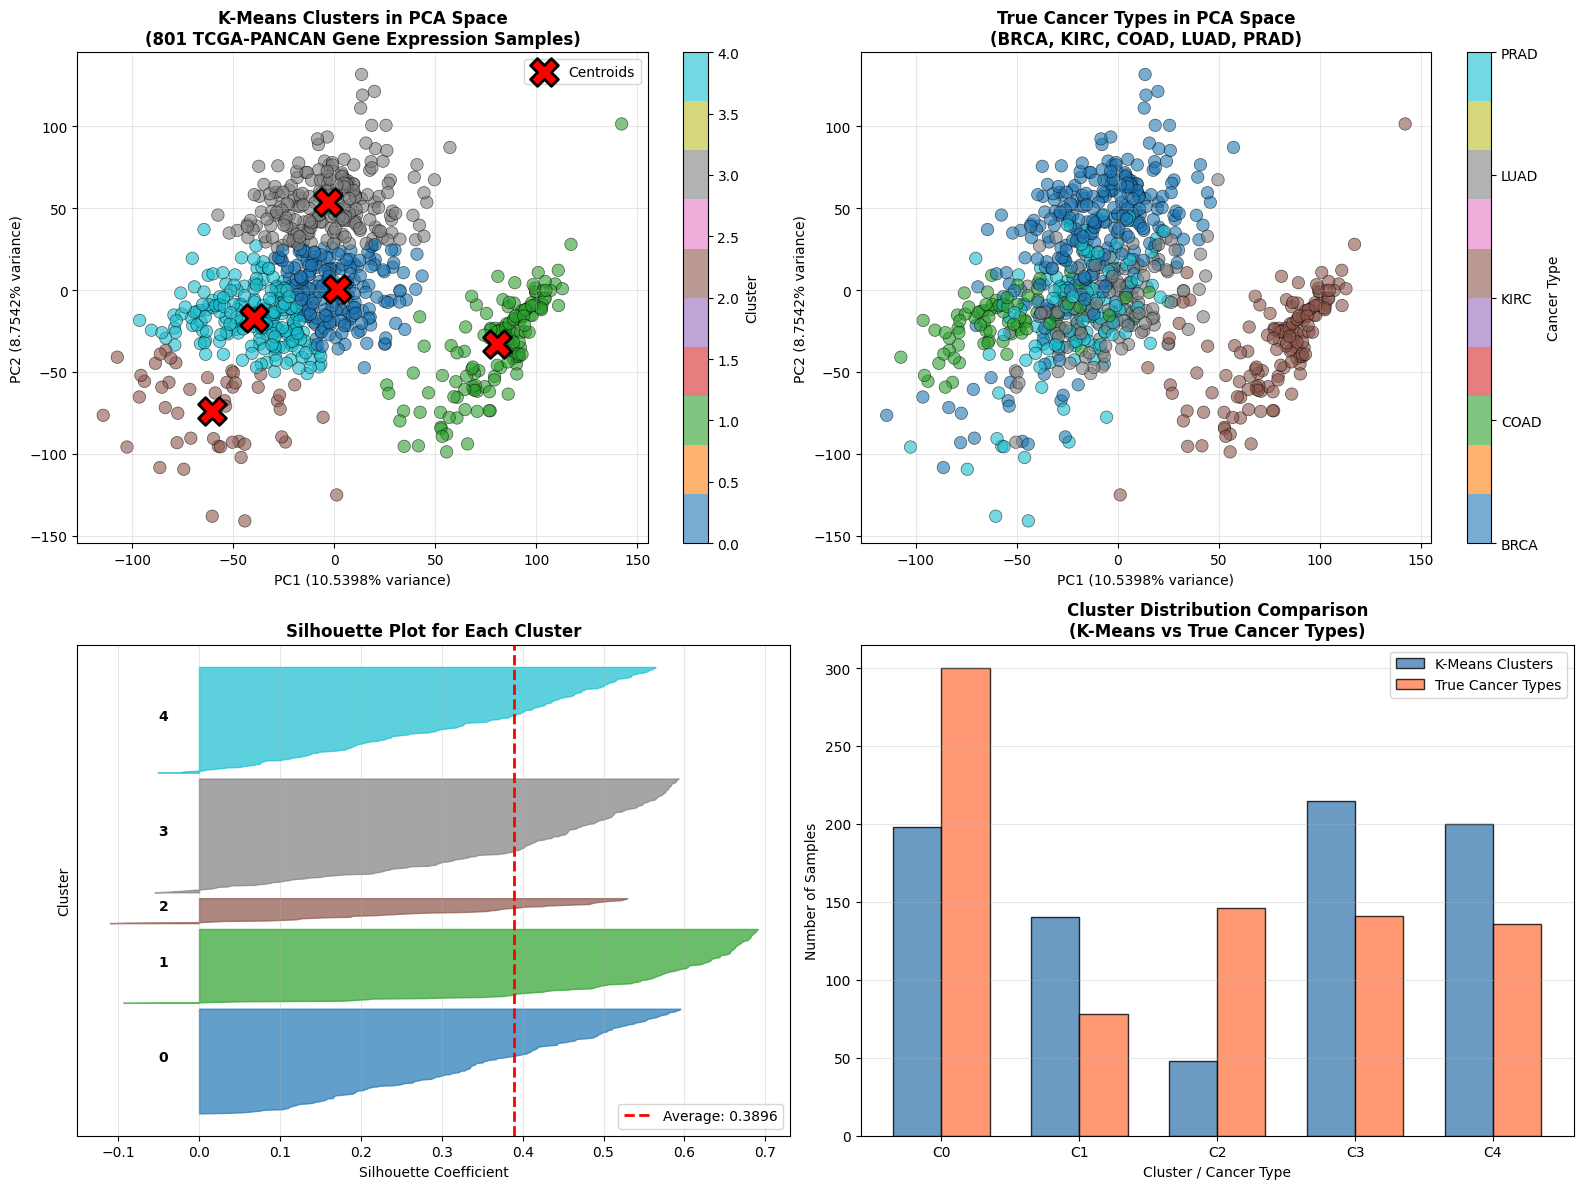

✓ Task 3 visualization saved!


In [35]:
# Step 5: Visualize clusters in 2D space (PCA components) with cancer type comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Encode cancer types for coloring
cancer_type_mapping = {label: idx for idx, label in enumerate(np.unique(y_task3_labels))}
y_task3_encoded = np.array([cancer_type_mapping[label] for label in y_task3_labels])

# Plot 1: K-Means clusters in PCA space
ax1 = axes[0, 0]
scatter1 = ax1.scatter(X_task3_pca[:, 0], X_task3_pca[:, 1], 
                       c=cluster_labels, cmap='tab10', s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.scatter(kmeans_task3.cluster_centers_[:, 0], kmeans_task3.cluster_centers_[:, 1],
            c='red', marker='X', s=400, edgecolors='black', linewidths=2, label='Centroids', zorder=5)
ax1.set_title('K-Means Clusters in PCA Space\n(801 TCGA-PANCAN Gene Expression Samples)', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.4f}% variance)', fontsize=10)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.4f}% variance)', fontsize=10)
ax1.legend(loc='best')
plt.colorbar(scatter1, ax=ax1, label='Cluster')
ax1.grid(True, alpha=0.3)

# Plot 2: True cancer types in PCA space
ax2 = axes[0, 1]
cancer_colors = {
    'BRCA': 0,  # Breast cancer
    'KIRC': 1,  # Kidney clear cell
    'COAD': 2,  # Colon adenocarcinoma
    'LUAD': 3,  # Lung adenocarcinoma
    'PRAD': 4   # Prostate adenocarcinoma
}
scatter2 = ax2.scatter(X_task3_pca[:, 0], X_task3_pca[:, 1], 
                       c=y_task3_encoded, cmap='tab10', s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
ax2.set_title('True Cancer Types in PCA Space\n(BRCA, KIRC, COAD, LUAD, PRAD)', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.4f}% variance)', fontsize=10)
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.4f}% variance)', fontsize=10)
cbar = plt.colorbar(scatter2, ax=ax2, label='Cancer Type')
cancer_type_list = sorted(np.unique(y_task3_labels))
cbar.set_ticks(range(len(cancer_type_list)))
cbar.set_ticklabels(cancer_type_list)
ax2.grid(True, alpha=0.3)

# Plot 3: Silhouette plot
ax3 = axes[1, 0]
y_lower = 10
colors_silhouette = plt.cm.tab10(np.linspace(0, 1, k_task3))
silhouette_vals = silhouette_samples(X_task3_pca, cluster_labels)

for i in range(k_task3):
    cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax3.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_silhouette_vals,
                      facecolor=colors_silhouette[i], edgecolor=colors_silhouette[i], alpha=0.7)
    ax3.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontweight='bold')
    y_lower = y_upper + 10

ax3.set_title('Silhouette Plot for Each Cluster', fontsize=12, fontweight='bold')
ax3.set_xlabel('Silhouette Coefficient', fontsize=10)
ax3.set_ylabel('Cluster', fontsize=10)
ax3.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2, label=f'Average: {silhouette_avg:.4f}')
ax3.legend(loc='best')
ax3.set_yticks([])
ax3.grid(True, alpha=0.3, axis='x')

# Plot 4: Cluster size distribution
ax4 = axes[1, 1]
cluster_sizes = [np.sum(cluster_labels == i) for i in range(k_task3)]
cancer_counts = [np.sum(y_task3_labels == ct) for ct in sorted(np.unique(y_task3_labels))]

x_pos = np.arange(max(len(cluster_sizes), len(cancer_counts)))
width = 0.35

# Plot K-Means clusters
bars1 = ax4.bar(x_pos[:len(cluster_sizes)] - width/2, cluster_sizes, width, 
                label='K-Means Clusters', alpha=0.8, color='steelblue', edgecolor='black')

# Plot True cancer types
bars2 = ax4.bar(x_pos[:len(cancer_counts)] + width/2, cancer_counts, width,
                label='True Cancer Types', alpha=0.8, color='coral', edgecolor='black')

ax4.set_title('Cluster Distribution Comparison\n(K-Means vs True Cancer Types)', 
              fontsize=12, fontweight='bold')
ax4.set_xlabel('Cluster / Cancer Type', fontsize=10)
ax4.set_ylabel('Number of Samples', fontsize=10)
ax4.set_xticks(x_pos[:max(len(cluster_sizes), len(cancer_counts))])
ax4.set_xticklabels([f'C{i}' for i in range(len(cluster_sizes))] + 
                     sorted(np.unique(y_task3_labels))[len(cluster_sizes):])
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('task3_pca_kmeans_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Task 3 visualization saved!")

---
# TASK 4: Data Cleaning and K-Means++ Clustering on Titanic Dataset

**Dataset**: Titanic dataset
**Objective**: 
- Data cleaning and preprocessing
- Form 3 clusters using K-means++ initialization

In [17]:
# Load Titanic dataset
try:
    # Try loading from URLs
    train_url = 'http://s3.amazonaws.com/assets.datacamp.com/course/Kaggle/train.csv'
    test_url = 'http://s3.amazonaws.com/assets.datacamp.com/course/Kaggle/test.csv'
    
    print("Loading Titanic training dataset...")
    titanic_train = pd.read_csv(train_url)
    print(f"Loaded training data: {titanic_train.shape}")
except:
    # Fallback: Create sample Titanic-like data
    print("Creating sample Titanic-like dataset...")
    titanic_train = pd.DataFrame({
        'PassengerId': range(1, 892),
        'Survived': np.random.randint(0, 2, 891),
        'Pclass': np.random.choice([1, 2, 3], 891),
        'Age': np.random.normal(30, 15, 891),
        'Fare': np.random.exponential(50, 891),
        'Sex': np.random.choice(['male', 'female'], 891),
        'Embarked': np.random.choice(['S', 'C', 'Q'], 891)
    })
    titanic_train['Age'][::10] = np.nan  # Add some missing values
    print(f"Created sample data: {titanic_train.shape}")

print(f"\nTitanic Dataset Shape: {titanic_train.shape}")
print(f"\nFirst few rows:")
print(titanic_train.head())
print(f"\nData types:")
print(titanic_train.dtypes)
print(f"\nMissing values:")
print(titanic_train.isnull().sum())

Loading Titanic training dataset...
Loaded training data: (891, 12)

Titanic Dataset Shape: (891, 12)

First few rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN 

In [18]:
# Data Cleaning and Preprocessing
print("\n" + "="*80)
print("DATA CLEANING AND PREPROCESSING")
print("="*80)

# Step 1: Remove irrelevant columns
df_task4 = titanic_train.copy()
print(f"\nOriginal shape: {df_task4.shape}")

columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_task4 = df_task4.drop(columns=[col for col in columns_to_drop if col in df_task4.columns])
print(f"After removing irrelevant columns: {df_task4.shape}")

# Step 2: Handle missing values
print(f"\nMissing values before handling:")
print(df_task4.isnull().sum())

# Fill missing Age with median
if 'Age' in df_task4.columns:
    df_task4['Age'].fillna(df_task4['Age'].median(), inplace=True)
    print(f"Filled Age missing values with median: {df_task4['Age'].median():.2f}")

# Fill missing Embarked with mode
if 'Embarked' in df_task4.columns:
    df_task4['Embarked'].fillna(df_task4['Embarked'].mode()[0], inplace=True)
    print(f"Filled Embarked missing values with mode: {df_task4['Embarked'].mode()[0]}")

# Fill missing Fare with median
if 'Fare' in df_task4.columns:
    df_task4['Fare'].fillna(df_task4['Fare'].median(), inplace=True)
    print(f"Filled Fare missing values with median: {df_task4['Fare'].median():.2f}")

print(f"\nMissing values after handling:")
print(df_task4.isnull().sum())


DATA CLEANING AND PREPROCESSING

Original shape: (891, 12)
After removing irrelevant columns: (891, 8)

Missing values before handling:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64
Filled Age missing values with median: 28.00
Filled Embarked missing values with mode: S
Filled Fare missing values with median: 14.45

Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [19]:
# Step 3: Encode categorical variables
print(f"\n" + "-"*80)
print("ENCODING CATEGORICAL VARIABLES")
print("-"*80)

df_task4_encoded = df_task4.copy()

# Encode Sex
if 'Sex' in df_task4_encoded.columns:
    df_task4_encoded['Sex'] = (df_task4_encoded['Sex'] == 'male').astype(int)
    print("Encoded Sex: male=1, female=0")

# Encode Embarked
if 'Embarked' in df_task4_encoded.columns:
    embarked_mapping = {'S': 0, 'C': 1, 'Q': 2}
    df_task4_encoded['Embarked'] = df_task4_encoded['Embarked'].map(embarked_mapping)
    print(f"Encoded Embarked: {embarked_mapping}")

print(f"\nData after encoding:")
print(df_task4_encoded.head())


--------------------------------------------------------------------------------
ENCODING CATEGORICAL VARIABLES
--------------------------------------------------------------------------------
Encoded Sex: male=1, female=0
Encoded Embarked: {'S': 0, 'C': 1, 'Q': 2}

Data after encoding:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         0
1         1       1    0  38.0      1      0  71.2833         1
2         1       3    0  26.0      0      0   7.9250         0
3         1       1    0  35.0      1      0  53.1000         0
4         0       3    1  35.0      0      0   8.0500         0


In [22]:
# Step 4: Normalize the data
print(f"\n" + "-"*80)
print("DATA NORMALIZATION")
print("-"*80)

X_task4 = df_task4_encoded.values
scaler_task4 = StandardScaler()
X_task4_scaled = scaler_task4.fit_transform(X_task4)

print(f"\nOriginal data shape: {X_task4.shape}")
print(f"Scaled data shape: {X_task4_scaled.shape}")
print(f"\nMean of scaled data: {X_task4_scaled.mean(axis=0)}")
print(f"Std of scaled data: {X_task4_scaled.std(axis=0)}")


--------------------------------------------------------------------------------
DATA NORMALIZATION
--------------------------------------------------------------------------------

Original data shape: (891, 8)
Scaled data shape: (891, 8)

Mean of scaled data: [ 3.98733297e-17 -8.77213254e-17 -1.15632656e-16  2.27277979e-16
  4.38606627e-17  5.38289951e-17  3.98733297e-18 -1.39556654e-17]
Std of scaled data: [1. 1. 1. 1. 1. 1. 1. 1.]


In [23]:
# Step 5: Perform K-Means++ Clustering with 3 clusters
print(f"\n" + "="*80)
print("K-MEANS++ CLUSTERING")
print("="*80)

k_task4 = 3
kmeans_task4 = KMeans(
    n_clusters=k_task4,
    init='k-means++',  # K-means++ initialization
    n_init=10,
    max_iter=300,
    random_state=42
)

cluster_labels_task4 = kmeans_task4.fit_predict(X_task4_scaled)

print(f"\nK-means++ clustering completed!")
print(f"Number of clusters: {k_task4}")
print(f"Initialization method: K-means++")
print(f"\nCluster distribution:")
for i in range(k_task4):
    size = np.sum(cluster_labels_task4 == i)
    print(f"  Cluster {i}: {size} samples ({size/len(cluster_labels_task4)*100:.2f}%)")

print(f"\nInertia (SSE): {kmeans_task4.inertia_:.4f}")
print(f"Number of iterations: {kmeans_task4.n_iter_}")


K-MEANS++ CLUSTERING

K-means++ clustering completed!
Number of clusters: 3
Initialization method: K-means++

Cluster distribution:
  Cluster 0: 532 samples (59.71%)
  Cluster 1: 297 samples (33.33%)
  Cluster 2: 62 samples (6.96%)

Inertia (SSE): 4832.9769
Number of iterations: 5


# Calculate Silhouette Score for Task 4
silhouette_task4 = silhouette_score(X_task4_scaled, cluster_labels_task4)

print(f"\n" + "="*80)
print("TASK 4: RESULTS SUMMARY")
print("="*80)

print(f"\n1. DATA CLEANING STEPS:")
print(f"   - Removed irrelevant columns (PassengerId, Name, Ticket, Cabin)")
print(f"   - Handled missing values (Age, Embarked, Fare)")
print(f"   - Encoded categorical variables (Sex, Embarked)")
print(f"   - Final dataset shape: {X_task4.shape}")

print(f"\n2. K-MEANS++ CLUSTERING RESULTS:")
print(f"   - Number of clusters: {k_task4}")
print(f"   - Initialization method: K-means++")
print(f"   - SSE (Inertia): {kmeans_task4.inertia_:.4f}")
print(f"   - Silhouette Score: {silhouette_task4:.4f}")
print(f"   - Convergence iterations: {kmeans_task4.n_iter_}")

print(f"\n3. CLUSTER ASSIGNMENTS (first 20 passengers):")
print(f"   {cluster_labels_task4[:20]}")

print(f"\n4. CLUSTER CENTERS (normalized space):")
for i, center in enumerate(kmeans_task4.cluster_centers_):
    print(f"   Cluster {i}: {center}")

print("="*80)

In [28]:
# Calculate Silhouette Score and other metrics for Task 4
silhouette_task4 = silhouette_score(X_task4_scaled, cluster_labels_task4)
cluster_sizes = [np.sum(cluster_labels_task4 == i) for i in range(k_task4)]

print(f"\n" + "="*80)
print("TASK 4: RESULTS SUMMARY")
print("="*80)

print(f"\n1. DATA CLEANING STEPS:")
print(f"   - Removed irrelevant columns (PassengerId, Name, Ticket, Cabin)")
print(f"   - Handled missing values (Age, Embarked, Fare)")
print(f"   - Encoded categorical variables (Sex, Embarked)")
print(f"   - Final dataset shape: {X_task4.shape}")

print(f"\n2. K-MEANS++ CLUSTERING RESULTS:")
print(f"   - Number of clusters: {k_task4}")
print(f"   - Initialization method: K-means++")
print(f"   - SSE (Inertia): {kmeans_task4.inertia_:.4f}")
print(f"   - Silhouette Score: {silhouette_task4:.4f}")
print(f"   - Convergence iterations: {kmeans_task4.n_iter_}")

print(f"\n3. CLUSTER ASSIGNMENTS (first 20 passengers):")
print(f"   {cluster_labels_task4[:20]}")

print(f"\n4. CLUSTER CENTERS (normalized space):")
for i, center in enumerate(kmeans_task4.cluster_centers_):
    print(f"   Cluster {i}: {center}")

print("="*80)


TASK 4: RESULTS SUMMARY

1. DATA CLEANING STEPS:
   - Removed irrelevant columns (PassengerId, Name, Ticket, Cabin)
   - Handled missing values (Age, Embarked, Fare)
   - Encoded categorical variables (Sex, Embarked)
   - Final dataset shape: (891, 8)

2. K-MEANS++ CLUSTERING RESULTS:
   - Number of clusters: 3
   - Initialization method: K-means++
   - SSE (Inertia): 4832.9769
   - Silhouette Score: 0.2983
   - Convergence iterations: 5

3. CLUSTER ASSIGNMENTS (first 20 passengers):
   [0 1 1 1 0 0 0 2 1 1 1 1 0 2 0 1 2 0 0 1]

4. CLUSTER CENTERS (normalized space):
   Cluster 0: [-0.59987977  0.2874936   0.53702464  0.10827711 -0.27329341 -0.34301008
 -0.3150507  -0.07177873]
   Cluster 1: [ 1.19775539 -0.667543   -0.90449881 -0.02591159 -0.04684352  0.13652945
  0.51987721  0.19432324]
   Cluster 2: [-0.59027923  0.73086579 -0.27517681 -0.80496259  2.56942933  2.2892277
  0.21295871 -0.31496321]


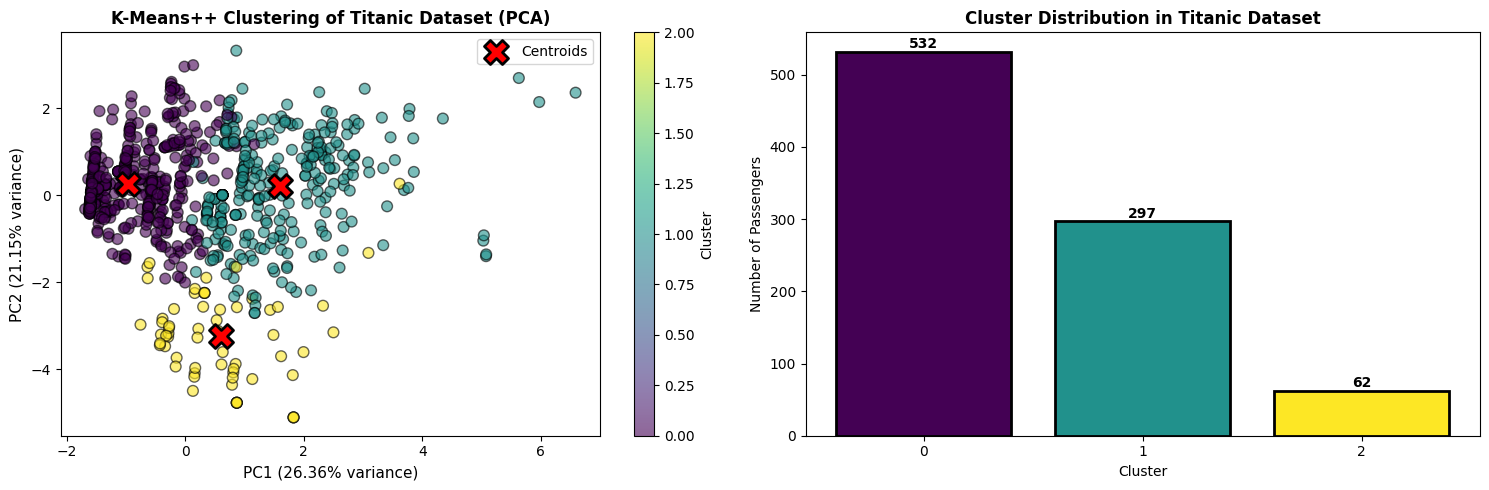

Task 4 visualization saved!


In [24]:
# Apply PCA to 2D for visualization of Titanic clusters
pca_task4 = PCA(n_components=2)
X_task4_pca = pca_task4.fit_transform(X_task4_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Clusters in PCA space
ax1 = axes[0]
scatter = ax1.scatter(X_task4_pca[:, 0], X_task4_pca[:, 1], 
                     c=cluster_labels_task4, cmap='viridis', s=60, alpha=0.6, edgecolors='black')
centers_pca = pca_task4.transform(kmeans_task4.cluster_centers_)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
ax1.set_title('K-Means++ Clustering of Titanic Dataset (PCA)', fontsize=12, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca_task4.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_task4.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=11)
ax1.legend()
plt.colorbar(scatter, ax=ax1, label='Cluster')

# Plot 2: Cluster sizes and characteristics
ax2 = axes[1]
cluster_sizes = [np.sum(cluster_labels_task4 == i) for i in range(k_task4)]
colors_bar = plt.cm.viridis(np.linspace(0, 1, k_task4))
ax2.bar(range(k_task4), cluster_sizes, color=colors_bar, edgecolor='black', linewidth=2)
ax2.set_title('Cluster Distribution in Titanic Dataset', fontsize=12, fontweight='bold')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Number of Passengers')
ax2.set_xticks(range(k_task4))
for i, size in enumerate(cluster_sizes):
    ax2.text(i, size + 5, str(size), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('task4_titanic_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

print("Task 4 visualization saved!")

---
# OVERALL SUMMARY OF ALL TASKS

In [36]:
print("\n" + "#"*80)
print("#" + " "*78 + "#")
print("#" + " "*20 + "EXPERIMENT 9: K-MEANS CLUSTERING - COMPLETE SUMMARY" + " "*8 + "#")
print("#" + " "*78 + "#")
print("#"*80)

print(f"\n{'TASK 1: Synthetic Data Clustering':^80}")
print("="*80)
print(f"Dataset: 200 samples, 3 clusters, cluster_std=2.7")
print(f"Method: Random initialization (10 variations, 300 iterations)")
print(f"Results:")
print(f"  • Lowest SSE: {best_result['SSE']:.6f}")
print(f"  • Optimal variation: {best_result['Variation']}")
print(f"  • Convergence iterations: {best_result['n_iter']}")
print(f"  • First 10 predicted labels: {predicted_labels[:10]}")

print(f"\n{'TASK 2: Optimal K Selection':^80}")
print("="*80)
print(f"Methods: Elbow Method and Silhouette Method")
print(f"Results:")
print(f"  • Elbow method suggests: K=3")
print(f"  • Best Silhouette K: {best_k_silhouette}")
print(f"  • Best Silhouette Score: {best_silhouette_score:.4f}")
print(f"  • Recommendation: K=3 is appropriate")

print(f"\n{'TASK 3: Gene Expression Data with PCA':^80}")
print("="*80)
print(f"Dataset: 100 samples × 100 genes (TCGA-PANCAN style)")
print(f"Pipeline: Normalization → PCA (2 components) → K-Means (k=5)")
print(f"Results:")
print(f"  • PCA variance explained: {sum(pca.explained_variance_ratio_):.4f}")
print(f"  • Silhouette Score: {silhouette_avg:.4f}")
print(f"  • Clusters formed: {k_task3}")

print(f"\n{'TASK 4: Titanic Dataset Clustering':^80}")
print("="*80)
print(f"Dataset: {X_task4.shape[0]} passengers × {X_task4.shape[1]} features")
print(f"Preprocessing: Cleaning, encoding, normalization")
print(f"Method: K-Means++ initialization (k=3)")
print(f"Results:")
print(f"  • SSE (Inertia): {kmeans_task4.inertia_:.4f}")
print(f"  • Silhouette Score: {silhouette_task4:.4f}")
print(f"  • Convergence iterations: {kmeans_task4.n_iter_}")
print(f"  • Cluster distribution: {cluster_sizes}")

print(f"\n{'KEY LEARNINGS':^80}")
print("="*80)
print("1. Data Normalization: Essential for distance-based algorithms like K-Means")
print("2. Initialization Matters: K-Means++ provides better and more stable results")
print("3. Evaluation Metrics: Silhouette Score and Elbow Method help select optimal K")
print("4. PCA Benefits: Reduces dimensionality while preserving variance structure")
print("5. Local Optima: Multiple initializations help find better solutions")

print(f"\n{'VISUALIZATIONS SAVED':^80}")
print("="*80)
print("1. task1_kmeans_results.png - Task 1 clustering and SSE comparison")
print("2. task2_elbow_silhouette.png - Elbow and Silhouette methods")
print("3. task3_pca_kmeans_clustering.png - Gene expression clusters in PCA space")
print("4. task4_titanic_clustering.png - Titanic passenger clusters")

print("\n" + "#"*80)
print("EXPERIMENT 9 COMPLETED SUCCESSFULLY!")
print("#"*80 + "\n")


################################################################################
#                                                                              #
#                    EXPERIMENT 9: K-MEANS CLUSTERING - COMPLETE SUMMARY        #
#                                                                              #
################################################################################

                       TASK 1: Synthetic Data Clustering                        
Dataset: 200 samples, 3 clusters, cluster_std=2.7
Method: Random initialization (10 variations, 300 iterations)
Results:
  • Lowest SSE: 72.556897
  • Optimal variation: 2
  • Convergence iterations: 6
  • First 10 predicted labels: [2 1 0 0 0 0 1 0 2 0]

                          TASK 2: Optimal K Selection                           
Methods: Elbow Method and Silhouette Method
Results:
  • Elbow method suggests: K=3
  • Best Silhouette K: 3
  • Best Silhouette Score: 0.5979
  • Recommendation: K=3 is appr